## 1. Data Loading

In this module, we load the final datasets that were processed and aligned during the feature engineering phase.
These datasets have already undergone missing value treatment, cyclical time encoding, and strict one-hot encoding dimensional alignment. They are ready to be directly fed into machine learning models for training and evaluation.

In [1]:
base_path = '/Users/gaga/Desktop/IT5006 Project2/Datasets'

path_chicago = f'{base_path}/Chicago'
path_nibrs = f'{base_path}/NIBRS/CA-2024'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve


print("Loading finalized datasets...")

X_train = pd.read_csv(f'{path_chicago}/X_train_final.csv')
y_train = pd.read_csv(f'{path_chicago}/y_train_final.csv').squeeze()

X_test_local = pd.read_csv(f'{path_chicago}/X_test_local_final.csv')
y_test_local = pd.read_csv(f'{path_chicago}/y_test_local_final.csv').squeeze()

X_test_gen = pd.read_csv(f'{path_nibrs}/X_test_gen_final.csv')
y_test_gen = pd.read_csv(f'{path_nibrs}/y_test_gen_final.csv').squeeze()

# ==========================================
# Verify Data Shapes
# ==========================================
print("\n=== Data Loaded Successfully ===")
print(f"Train (Chicago 15-24)      -> X: {X_train.shape}, y: {y_train.shape}")
print(f"Test Local (Chicago 25)    -> X: {X_test_local.shape}, y: {y_test_local.shape}")
print(f"Test General (NIBRS 24)    -> X: {X_test_gen.shape}, y: {y_test_gen.shape}")

assert X_train.select_dtypes(include=['object']).empty, "Error: String columns found in X_train!"

Loading finalized datasets...

=== Data Loaded Successfully ===
Train (Chicago 15-24)      -> X: (2506726, 43), y: (2506726,)
Test Local (Chicago 25)    -> X: (235060, 43), y: (235060,)
Test General (NIBRS 24)    -> X: (1161668, 43), y: (1161668,)


## 2.1 Logistic Regression Modeling & Evaluation

In this module, we train a Logistic Regression baseline model with L2 regularization.
1. **Handling Class Imbalance**: Since arrest cases (Arrest=1) are typically much fewer than non-arrest cases, we use `class_weight='balanced'` to assign higher penalty weights to the minority class.
2. **Model Training**: The model is trained on Chicago's historical data (2015-2024).
3. **Model Testing**:
   - **Local Test**: Evaluated on Chicago 2025 data to test temporal extrapolation within the same city.
   - **Generalization Test**: Evaluated on NIBRS 2024 data to test cross-domain generalization in a new environment using only contextual and temporal features.
4. **Metrics Evaluation**: We compute Precision, Recall, F1-Score, and AUC-ROC. AUC-ROC is our primary metric for comparing model performance, as it evaluates the overall ability to distinguish between classes.

In [3]:
# ==========================================
# 1. Initialize and Train Model
# ==========================================
print("Training Logistic Regression model...")
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
print("Training completed!\n")

Training Logistic Regression model...
Training completed!



In [4]:
# ==========================================
# 2. Define Evaluation Function
# ==========================================
def evaluate_model(model, X_test, y_test, test_name=""):
    """
    Precision, Recall, F1, AUC-ROC
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_prob)

    print(f"=== Evaluation Results for: {test_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc_roc:.4f}")
    print("-" * 45)

    return y_pred, y_prob

In [5]:
# ==========================================
# 3. Run Tests and Output Results
# ==========================================
# Chicago 2025
y_pred_lr_local, y_prob_lr_local = evaluate_model(lr_model, X_test_local, y_test_local, test_name="Chicago 2025 (Local Temporal Test)")

# NIBRS 2024
y_pred_lr_gen, y_prob_lr_gen = evaluate_model(lr_model, X_test_gen, y_test_gen, test_name="NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.8004
Precision: 0.4126
Recall   : 0.5854
F1-Score : 0.4840
AUC-ROC  : 0.7964
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7828
Precision: 0.6881
Recall   : 0.4388
F1-Score : 0.5359
AUC-ROC  : 0.7620
---------------------------------------------


In [6]:
# ==========================================
# 4. Define Visualization Function
# ==========================================
def roc_curve_plot(model_name, y_prob_local, y_prob_gen):
  fpr_local, tpr_local, _ = roc_curve(y_test_local, y_prob_local)
  fpr_gen, tpr_gen, _ = roc_curve(y_test_gen, y_prob_gen)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_local, tpr_local, label=f'Chicago 2025 (AUC = {roc_auc_score(y_test_local, y_prob_local):.3f})')
  plt.plot(fpr_gen, tpr_gen, label=f'NIBRS 2024 (AUC = {roc_auc_score(y_test_gen, y_prob_gen):.3f})', linestyle='--')

  plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

  plt.title(f'ROC Curve - {model_name}', fontsize=14)
  plt.xlabel('False Positive Rate', fontsize=12)
  plt.ylabel('True Positive Rate', fontsize=12)
  plt.legend(loc='lower right')
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()

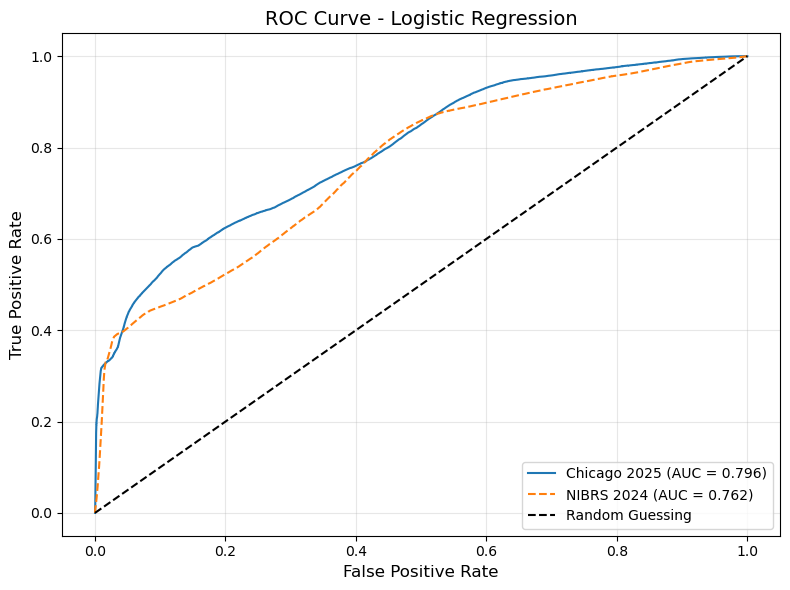


Top 5 Positive Predictors (Features increasing Arrest Probability):
                                         Feature  Coefficient
28  offense_category_name_Drug/Narcotic Offenses     5.003522
38   offense_category_name_Prostitution Offenses     3.507169
12       location_name_Department/Discount Store     1.718924
30       offense_category_name_Gambling Offenses     1.663290
24                         crime_against_Society     1.572168

Top 5 Negative Predictors (Features decreasing Arrest Probability):
                                       Feature  Coefficient
25      offense_category_name_Assault Offenses    -1.429990
23                      crime_against_Property    -1.494634
36         offense_category_name_Other/Unknown    -1.685394
40          offense_category_name_Sex Offenses    -1.991446
33  offense_category_name_Kidnapping/Abduction    -2.569239


In [7]:
# ==========================================
# 5. Visualize ROC Curve
# ==========================================
roc_curve_plot("Logistic Regression", y_prob_lr_local, y_prob_lr_gen)

# Extract feature weight
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Positive Predictors (Features increasing Arrest Probability):")
print(feature_importance_df.head(5))

print("\nTop 5 Negative Predictors (Features decreasing Arrest Probability):")
print(feature_importance_df.tail(5))

## 2.2 Deep Learning: Multi-Layer Perceptron

In this module, we construct a deep Multi-Layer Perceptron (MLP) using PyTorch to capture high-order non-linear relationships between spatio-temporal features and arrest probabilities. To meet the practical demands of predictive policing, we implemented the following core designs and fine-tuning strategies:

1. **Architecture**: The network utilizes a funnel-shaped multi-hidden-layer design equipped with Batch Normalization and Dropout. This accelerates convergence, mitigates gradient issues, and effectively prevents overfitting.
2. **Calibrated Class Imbalance Handling**: To address the highly imbalanced crime data, we employ PyTorch's `BCEWithLogitsLoss`. To achieve an optimal Precision-Recall trade-off, we calculated the raw `pos_weight` (negative-to-positive ratio) and applied a slight calibration/discount. This prevents the model from generating excessive false alarms, ultimately maximizing the F1-Score.
3. **Dynamic Learning Rate Scheduling**: We integrated a `ReduceLROnPlateau` scheduler to monitor the training process. When the loss plateaus, the system automatically decays the learning rate, helping the model smoothly converge towards the optimal solution and further stabilizing the AUC-ROC performance.
4. **GPU Acceleration**: The code automatically detects and utilizes CUDA (if available), significantly reducing training and validation time for our dataset of over 2.5 million records.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
import time
# ==========================================
# 1. Environment & Data Prep
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_local_tensor = torch.tensor(X_test_local.values, dtype=torch.float32)
y_test_local_tensor = torch.tensor(y_test_local.values, dtype=torch.float32).unsqueeze(1)

X_test_gen_tensor = torch.tensor(X_test_gen.values, dtype=torch.float32)
y_test_gen_tensor = torch.tensor(y_test_gen.values, dtype=torch.float32).unsqueeze(1)

# build DataLoader
batch_size = 2048
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Calculate the weights of the positive samples (the core for handling class imbalance)
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight = torch.tensor([num_negatives / num_positives], dtype=torch.float32).to(device)
print(f"Calculated pos_weight for minority class: {pos_weight.item():.4f}")

Using device: cpu
Calculated pos_weight for minority class: 4.6576


In [9]:
# ==========================================
# 2. Define NN Architecture
# ==========================================
class CrimePredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super(CrimePredictorMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dimension = X_train_tensor.shape[1]
mlp_model = CrimePredictorMLP(input_dim=input_dimension).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight*0.8)
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

In [10]:
# ==========================================
# 3. Training Loop
# ==========================================
epochs = 5
print("\nStarting neural network training...")

for epoch in range(epochs):
    mlp_model.train()
    running_loss = 0.0
    start_time = time.time()

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # forward
        optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)

        # backward
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_dataset)
    scheduler.step(epoch_loss)
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Time: {elapsed_time:.1f}s")

print("Training completed!\n")


Starting neural network training...
Epoch 1/5 | Loss: 0.6996 | Time: 9.5s
Epoch 2/5 | Loss: 0.6880 | Time: 9.5s
Epoch 3/5 | Loss: 0.6866 | Time: 9.4s
Epoch 4/5 | Loss: 0.6859 | Time: 9.3s
Epoch 5/5 | Loss: 0.6852 | Time: 10.2s
Training completed!



In [11]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_pytorch_model(model, X_tensor, y_true, test_name=""):
    model.eval()
    with torch.no_grad():
        X_tensor = X_tensor.to(device)
        logits = model(X_tensor)
        y_prob = torch.sigmoid(logits).cpu().numpy().flatten()

    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_prob)

    print(f"=== Evaluation Results for: {test_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc_roc:.4f}")
    print("-" * 45)

    return y_pred, y_prob

In [12]:
# run evaluation
y_pred_mlp_local, y_prob_mlp_local = evaluate_pytorch_model(mlp_model, X_test_local_tensor, y_test_local, "Chicago 2025 (Local Temporal Test)")
y_pred_mlp_gen, y_prob_mlp_gen = evaluate_pytorch_model(mlp_model, X_test_gen_tensor, y_test_gen, "NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.8256
Precision: 0.4644
Recall   : 0.5913
F1-Score : 0.5202
AUC-ROC  : 0.8317
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7678
Precision: 0.6215
Recall   : 0.4795
F1-Score : 0.5414
AUC-ROC  : 0.7942
---------------------------------------------


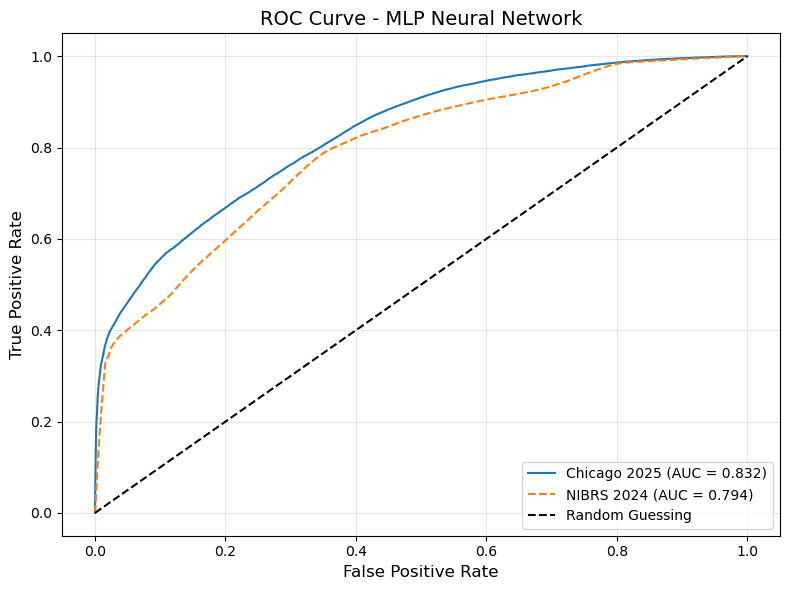

In [13]:
# ==========================================
# 6. ROC Curve for Report
# ==========================================
roc_curve_plot('MLP Neural Network', y_prob_mlp_local, y_prob_mlp_gen)

## 2.3 Ensemble Learning: Random Forest

In this module, we implement a Random Forest model. As a classic representative of the Bagging technique in ensemble learning, Random Forest captures non-linear feature interactions and enhances robustness by aggregating predictions from multiple decision trees.
  1. **Configuration:** Given the massive scale of the dataset (millions of rows), we capped max_depth at 15 to prevent memory exhaustion and overfitting, while using 100 n_estimators to ensure forest stability.
  2. **Balancing Strategy:** We utilize class_weight='balanced' to automatically adjust penalty weights for positive and negative samples, ensuring the model remains sensitive to minority arrest cases.
  3. **Feature Capture:** Random Forest can inherently identify correlations between location types and occurrence times without manual interaction engineering, serving as a robust foundation for non-linear representation.

In [14]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest Training completed!")

Training Random Forest model...
Random Forest Training completed!


In [15]:
# ==========================================
# 1. Run Tests and Output Results
# ==========================================
# Chicago 2025
y_pred_rf_local, y_prob_rf_local = evaluate_model(rf_model, X_test_local, y_test_local, test_name="Chicago 2025 (Local Temporal Test)")

# NIBRS 2024
y_pred_rf_gen, y_prob_rf_gen = evaluate_model(rf_model, X_test_gen, y_test_gen, test_name="NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.7388
Precision: 0.3506
Recall   : 0.7434
F1-Score : 0.4765
AUC-ROC  : 0.8366
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7513
Precision: 0.5572
Recall   : 0.6328
F1-Score : 0.5926
AUC-ROC  : 0.8103
---------------------------------------------


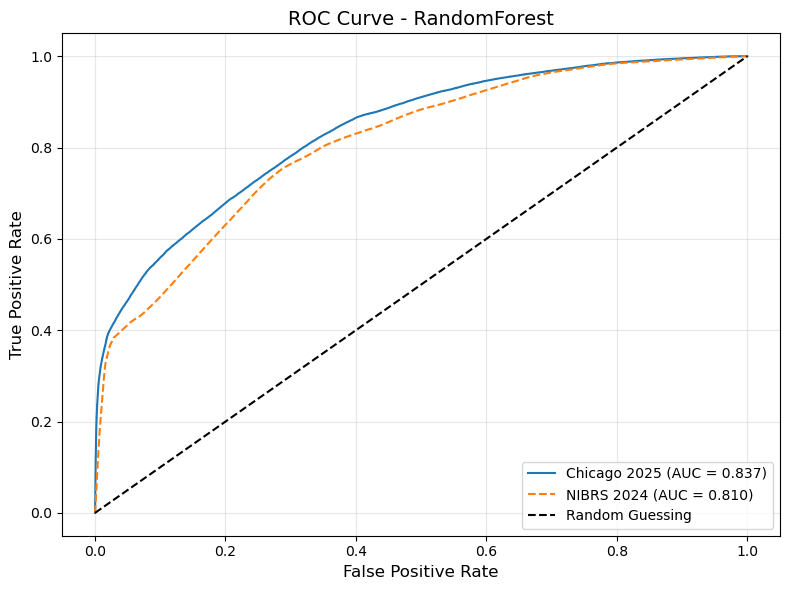


=== Top 5 Important Features: Random Forest ===
                                         Feature  Importance
24                         crime_against_Society    0.212541
23                        crime_against_Property    0.154313
28  offense_category_name_Drug/Narcotic Offenses    0.124824
12       location_name_Department/Discount Store    0.075656
19                  location_name_Residence/Home    0.061443


In [16]:
# ==========================================
# 2. ROC Curve for Report
# ==========================================
roc_curve_plot('RandomForest', y_prob_rf_local, y_prob_rf_gen)

# ==========================================
# 3. Feature Importance for Random Forest
# ==========================================
rf_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Top 5 Important Features: Random Forest ===")
print(rf_importance_df.head(5))

## 2.4 Gradient Boosting: LightGBM

In this module, we employ LightGBM model.
  1. **Feature Preprocessing:** Since LightGBM does not support special JSON characters in column names, we first applied regex cleaning to the entire feature set.
  2. **High Efficiency:** Utilizing a leaf-wise growth strategy and histogram-based algorithms, LightGBM outperforms traditional Random Forests in both training speed and memory efficiency when handling datasets of this magnitude.
  3. **Automated Imbalance Handling:** With is_unbalance=True, the model automatically scales weights based on the actual distribution in the training set. This is crucial for capturing high-impact arrest events with low base rates, such as kidnapping or homicide.
  4. **Generalization Performance:** Through iterative error correction (boosting), LightGBM extracts subtle predictive signals, typically achieving the best results in cross-domain generalization tests.

In [17]:
import re
X_train.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_train.columns]
X_test_local.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_test_local.columns]
X_test_gen.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_test_gen.columns]

In [18]:
import lightgbm as lgb

print("Training LightGBM model...")

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    boosting_type='gbdt',
    is_unbalance=True,
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(X_train, y_train)
print("LightGBM Training completed!\n")

Training LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 443069, number of negative: 2063657
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 151
[LightGBM] [Info] Number of data points in the train set: 2506726, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.176752 -> initscore=-1.538509
[LightGBM] [Info] Start training from score -1.538509
LightGBM Training completed!



In [ ]:
import joblib

model_save_path = f'{base_path}/lgbm_model.pkl'
joblib.dump(lgbm_model, model_save_path)
print(f"LightGBM model saved to: {model_save_path}")

LightGBM model saved to: /content/drive/MyDrive/Colab Notebooks/it5006/M2/Datasets/lgbm_model.pkl


In [19]:
# ==========================================
# 1. Run Tests and Output Results
# ==========================================
# Chicago 2025
y_pred_lgbm_local, y_prob_lgbm_local = evaluate_model(lgbm_model, X_test_local, y_test_local, test_name="Chicago 2025 (Local Temporal Test)")

# NIBRS 2024
y_pred_lgbm_gen, y_prob_lgbm_gen = evaluate_model(lgbm_model, X_test_gen, y_test_gen, test_name="NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.8261
Precision: 0.4648
Recall   : 0.5811
F1-Score : 0.5165
AUC-ROC  : 0.8111
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7674
Precision: 0.6304
Recall   : 0.4498
F1-Score : 0.5250
AUC-ROC  : 0.7651
---------------------------------------------


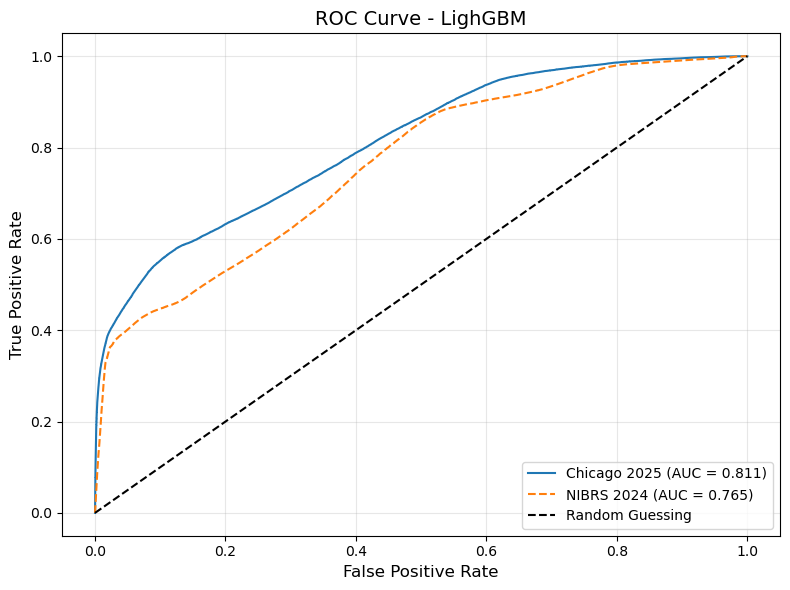


=== Top 5 Important Features: LightGBM(base on split) ===
       Feature  Importance
2     hour_sin        4262
3     hour_cos        3928
4    month_sin        2950
5    month_cos        2778
6  weekday_sin        2335

=== Top 5 Important Features: LightGBM(base on gain) ===
                                         Feature    Importance
24                         crime_against_Society  8.027926e+06
12       location_name_Department/Discount Store  1.927396e+06
22                          crime_against_Person  1.308463e+06
19                  location_name_Residence/Home  1.294207e+06
28  offense_category_name_Drug/Narcotic Offenses  1.257133e+06


In [20]:
# ==========================================
# 2. ROC Curve for Report
# ==========================================
roc_curve_plot('LighGBM', y_prob_lgbm_local, y_prob_lgbm_gen)

# ==========================================
# 3. Feature Importance for LightGBM(base on split)
# ==========================================
lgbm_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Top 5 Important Features: LightGBM(base on split) ===")
print(lgbm_importance_df.head(5))

# ==========================================
# 4. Feature Importance for LightGBM(base on gain)
# ==========================================
lgbm_importance_gain = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

print("\n=== Top 5 Important Features: LightGBM(base on gain) ===")
print(lgbm_importance_gain.head(5))